In [1]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew 
import warnings

In [2]:
# Setting seaborn style and colours
sns.set_style("whitegrid")
sns.color_palette("muted", 10)
sns.set_palette("muted", 10)

## Pageviews exploration 
1. What was the most seen Artsy page in this dataset?

2. Artsy has thousands of unique urls for artworks, articles, and other entities on its site. Can you think of any way to categorize these pages into "types"? Categorize the most common ones.

3. Please provide code that would add a new column to a dataframe of pageviews in Python (pandas) or R containing the page type you’ve defined.

4. What is the breakdown of pageviews of each page type (as you’ve defined them) for logged in visitors? For logged out? What are some observations you can make about users' behavior on Artsy?

**Overview**

In [3]:
url="https://artsy-data.s3.amazonaws.com/public/data_test_pageviews.csv"
views=pd.read_csv(url)

In [4]:
views.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   anonymous_id  100000 non-null  object
 1   logged_in     100000 non-null  bool  
 2   received_at   100000 non-null  object
 3   path          100000 non-null  object
 4   referrer      80035 non-null   object
dtypes: bool(1), object(4)
memory usage: 3.1+ MB


In [5]:
views.head(5)

,anonymous_id,logged_in,received_at,path,referrer
0,ad31b961-d67f-497c-9def-9193d518863a,False,2017-03-12 18:23:28.241,/artist/anish-kapoor,http://m.facebook.com
1,dd14cc5c-f31a-4591-974d-1233346b1999,False,2017-03-20 20:36:32.177,/artwork/vernon-fisher-happy-family,NaN
2,9b459a76-aaa3-44cd-9f0e-af7fb9829b2c,False,2017-03-14 05:19:47.852,/article/francesca-gavin-10-new-artists-to-wat...,https://www.google.ge/
3,cb745df7-c90d-4339-9519-960081515b8c,False,2017-03-14 02:50:29.697,/article/artsy-editorial-8-female-surrealists-...,https://l.facebook.com/l.php?u=https%3A%2F%2Fw...
4,8b18968d-4e51-4e00-b60c-d80b1ad6a55c,False,2017-03-15 09:07:07.436,/article/artsy-editorial-why-these-7-artists-q...,https://www.facebook.com/


### 1. What was the most seen Artsy page in this dataset?

In [6]:
views["path"].value_counts().sort_values(ascending=False)

/                                                                                                        4283
/search                                                                                                  2603
/collect                                                                                                 1643
/article/artsy-editorial-photographs-womens-bodies-instagram-censored                                    1265
/artists                                                                                                 1191
                                                                                                         ... 
/artwork/francisco-benitez-the-secret-garden                                                                1
/artwork/fabio-barile-eastern-wall-of-corno-piccolo-gran-sasso-ditalia-massif-abruzzo-italy-diptych-1       1
/artwork/arman-arteriosclerose                                                                              1
/artwork/k

**Results**
The starting page was the mosten often visited Artsy page


### 2. Artsy has thousands of unique urls for artworks, articles, and other entities on its site. Can you think of any way to categorize these pages into "types"? Categorize the most common ones.

In [7]:
# creating a list with the the first elemente of the path provided, since it tells you the type of the page
pagetype = []
for ele in views["path"]:
    typ = ele.split("/")[1]
    pagetype.append(typ)
#print(pagetype)
#len(pagetype)

In [8]:
# Python code to count the number of occurrences 
counts = dict()
for page in pagetype:
    if page not in counts:
        counts[page] = 1
    else:
        counts[page] = counts[page]+1
        
#print(counts)

In [9]:
sort = []
for k,v in counts.items():
    sort.append((v,k))
sort = sorted(sort, reverse=True)
#print(sort)

**The 10 most commen URL-types: artist(s), article(s), artwork(s), show(s), search, collect, gene, auction(s), galleries, other** 

### 3. Please provide code that would add a new column to a dataframe of pageviews in Python (pandas) or R containing the page type you’ve defined.

In [10]:
# creating a new column 
views["page_type"]=pagetype

In [11]:
page_type_cat = {'artist':'Artist',
'artists':'Artist',
'article':'Article',
'article':'Article',
'show':'Show',
'artwork':'Artwork',
'artworks':'Artwork',
'collect': 'Collect',
'gene':'Gene',
'auction':'Auction',
'auctions':'Auction',
'gallery':'Gallery',
'galleries':'Gallery',
'search':'Search'
}

In [12]:
views['Type'] = views['page_type'].map(page_type_cat)

In [13]:
views["Type"].fillna("other", inplace=True)

In [14]:
views["Type"].value_counts()

Artist     28813
Article    23487
Artwork    22500
other      13892
Show        3327
Search      2603
Auction     1802
Collect     1644
Gene        1442
Gallery      490
Name: Type, dtype: int64

In [15]:
#views.head(50)

### 4. What is the breakdown of pageviews of each page type (as you’ve defined them) for logged in visitors? For logged out? What are some observations you can make about users' behavior on Artsy?

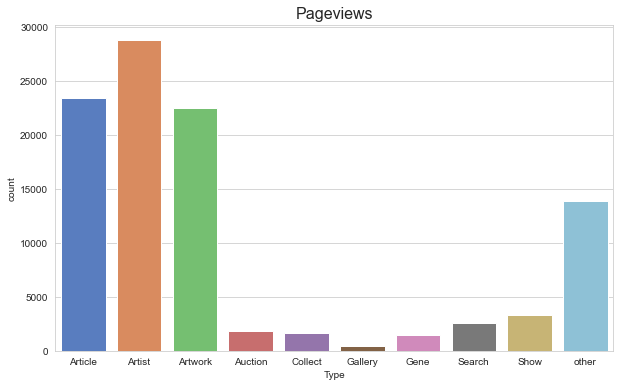

In [16]:
plt.figure(figsize=(10,6))
plt.title("Pageviews", fontsize=16);
sns.countplot(x='Type', data=views.sort_values("Type"));

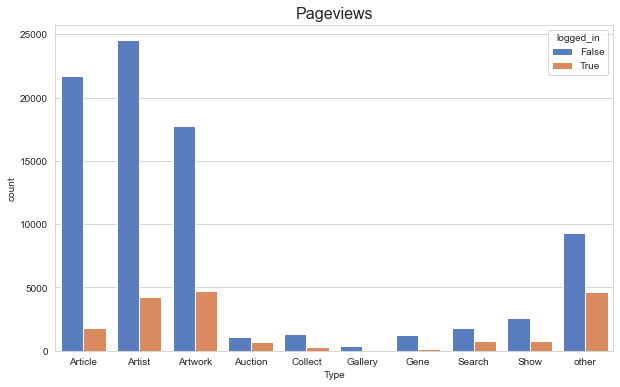

In [17]:
plt.figure(figsize=(10,6))
plt.title("Pageviews", fontsize=16);
sns.countplot(x='Type', hue="logged_in", data=views.sort_values("Type"));

In [18]:
views.groupby("Type")["logged_in"].value_counts()

Type     logged_in
Article  False        21680
         True          1807
Artist   False        24527
         True          4286
Artwork  False        17777
         True          4723
Auction  False         1072
         True           730
Collect  False         1317
         True           327
Gallery  False          393
         True            97
Gene     False         1287
         True           155
Search   False         1790
         True           813
Show     False         2576
         True           751
other    False         9262
         True          4630
Name: logged_in, dtype: int64

**Results**
1. Most pageviews are at artists, follwed by articles and artworks.
2. Most of the user do not log in when using artsy. The highest count of logged in user is for viewing Artwork.

#### Where do user come from?

In [19]:
views["referrer"].value_counts()

https://www.google.com/                                                                                                                                                                                         8678
https://www.facebook.com/                                                                                                                                                                                       4575
https://www.artsy.net/                                                                                                                                                                                          3223
http://m.facebook.com                                                                                                                                                                                           2296
https://www.google.co.uk/                                                                                                                           

**Results**
Most user come from google, facebook and the starting page of artsy

In [20]:
# creating seperate date and time columns
views['Dates'] = pd.to_datetime(views['received_at']).dt.date
views['Time'] = pd.to_datetime(views['received_at']).dt.time
views['Hour'] = pd.to_datetime(views['received_at']).dt.hour

In [21]:
#views.head(50)

In [22]:
time = []
for ele in views["Hour"]:
    if ele >=5 and ele<10:
        time.append("morning")
    elif ele >= 10 and ele<12:
        time.append("forenoon")
    elif ele >=12 and ele<14:
        time.append("noon")
    elif ele >=14 and ele<18:
        time.append("afternoon")
    elif ele >=18 and ele<23:
        time.append("evening")
    else:
        time.append("night")
#print(time)

In [26]:
views["Time_of_Day"]=time
#views.head(30)

In [24]:
views["Time_of_Day"].value_counts()

evening      27207
afternoon    22660
night        22050
morning      12603
noon          8687
forenoon      6793
Name: Time_of_Day, dtype: int64

**Results**
Most pageviews happen during the evening, followed by afternoon and night.

In [25]:
views.groupby("Type")["Time_of_Day"].value_counts()

Type     Time_of_Day
Article  evening        5718
         night          5583
         afternoon      5347
         morning        3152
         noon           2174
         forenoon       1513
Artist   evening        7967
         afternoon      6393
         night          6288
         morning        3517
         noon           2570
         forenoon       2078
Artwork  evening        6453
         night          5071
         afternoon      4905
         morning        2725
         noon           1908
         forenoon       1438
Auction  evening         581
         afternoon       485
         night           387
         morning         174
         forenoon         89
         noon             86
Collect  evening         463
         afternoon       363
         night           353
         morning         228
         noon            127
         forenoon        110
Gallery  evening         132
         afternoon       114
         night            98
         morning      

**Results**
The pattern of time of pageviews does not differ between types of URLs.